In [1]:
import os
# The jupyter notebook is launched from your $HOME directory.
# Change the working directory to your username directory under /scratch/cd82
os.chdir(os.path.expandvars("/scratch/cd82/$USER/"))

# Image Classification with Convolutional Neural Networks

## Episode 05 Evaluate a Convolutional Neural Network and Make Predictions (Classifications)

## Step 9. Tune hyperparameters

## CHALLENGE Tune Dropout Rate (Model Build) using a For Loop


In [2]:
# load the required packages
from tensorflow import keras # data and neural network
from sklearn.model_selection import train_test_split # data splitting
import seaborn as sns # specialised plotting
import pandas as pd # handles dataframes

2025-08-20 11:12:36.059545: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-20 11:12:36.062280: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 11:12:36.153244: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 11:12:36.154520: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-20 11:12:38.484827: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [3]:
# function to prepare the training dataset
def prepare_dataset(train_images, train_labels):
    
    # normalize the RGB values to be between 0 and 1
    train_images = train_images / 255.0
    
    # one hot encode the training labels
    train_labels = keras.utils.to_categorical(train_labels, len(class_names))
    
    # split the training data into training and validation set
    train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size = 0.2, random_state=42)

    return train_images, val_images, train_labels, val_labels

In [4]:
# load the data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# create a list of classnames
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# prepare the dataset for training
train_images, val_images, train_labels, val_labels = prepare_dataset(train_images, train_labels)

# prepare test dataset
# normalize the RGB values to be between 0 and 1
test_images = test_images / 255.0

## Step 9. Tune hyperparameters

Hyperparameters are the parameters set by the person configuring the model instead of those learned by the algorithm itself. Like the dials on a radio which are tuned to the best frequency, hyperparameters can be tuned to the best combination for a given model and context.

## CHALLENGE Tune Dropout Rate (Model Build) using a For Loop

Q1. What do you think would happen if you lower the dropout rate? Write some code to vary the dropout rate and investigate how it affects the model training.

Hint 1: Modify the 'create_model_dropout()' function and define a `create_model_dropout_vary()` function that has `dropout_rate` as its only parameter.
    
Hint 2: Use a for loop to call your function with varying dropout rates

Q2. You are varying the dropout rate and checking its effect on the model performance, what is the term associated to this procedure?

In [5]:
## SOLUTION


## SOLUTION

In [6]:
# define new dropout function that accepts a dropout rate
def create_model_dropout_vary(dropout_rate):
    
    # Input layer of 32x32 images with three channels (RGB)
    inputs_vary = keras.Input(shape=train_images.shape[1:])
    
    # CNN Part 2
    # Convolutional layer with 16 filters, 3x3 kernel size, and ReLU activation
    x_vary = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu')(inputs_vary)
    # Pooling layer with input window sized 2x2
    x_vary = keras.layers.MaxPooling2D(pool_size=(2,2))(x_vary)
    # Second Convolutional layer with 32 filters, 3x3 kernel size, and ReLU activation
    x_vary = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(x_vary)
    # Second Pooling layer with input window sized 2x2
    x_vary = keras.layers.MaxPooling2D(pool_size=(2,2))(x_vary)
    # Second Convolutional layer with 64 filters, 3x3 kernel size, and ReLU activation
    x_vary = keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')(x_vary)
    # Dropout layer randomly drops x% of the input units
    x_vary = keras.layers.Dropout(rate=dropout_rate)(x_vary) # This is new!
    # Flatten layer to convert 2D feature maps into a 1D vector
    x_vary = keras.layers.Flatten()(x_vary)
    
    # CNN Part 3
    # Output layer with 10 units (one for each class) and softmax activation
    outputs_vary = keras.layers.Dense(units=10, activation='softmax')(x_vary)

    model_vary = keras.Model(inputs = inputs_vary, 
                             outputs = outputs_vary, 
                             name ="cifar_model_dropout_vary")

    return model_vary

2025-08-20 11:12:50.018555: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/10
1250/1250 [==============================] - 9s 6ms/step - loss: 1.6061 - categorical_accuracy: 0.4139 - val_loss: 1.3670 - val_categorical_accuracy: 0.5150
Epoch 2/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.2911 - categorical_accuracy: 0.5415 - val_loss: 1.1882 - val_categorical_accuracy: 0.5800
Epoch 3/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.1511 - categorical_accuracy: 0.5957 - val_loss: 1.1177 - val_categorical_accuracy: 0.6114
Epoch 4/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.0614 - categorical_accuracy: 0.6293 - val_loss: 1.0852 - val_categorical_accuracy: 0.6174
Epoch 5/10
1250/1250 [==============================] - 7s 6ms/step - loss: 0.9979 - categorical_accuracy: 0.6515 - val_loss: 1.0158 - val_categorical_accuracy: 0.6467
Epoch 6/10
1250/1250 [==============================] - 7s 5ms/step - loss: 0.9458 - categorical_accuracy: 0.6701 - val_loss: 0.9463 - val_categorical_accuracy:

<Axes: xlabel='dropout_rate', ylabel='val_loss_vary'>

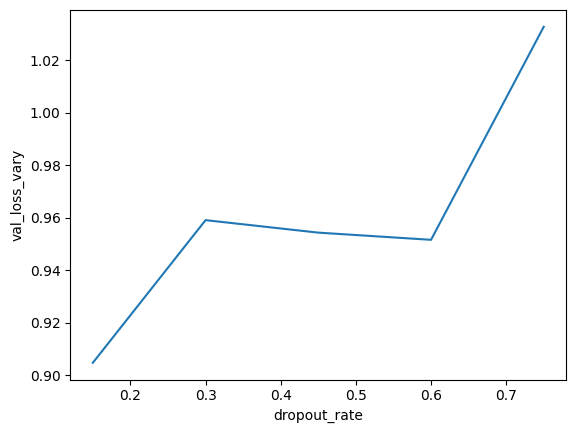

In [7]:
# specify range of dropout rates
dropout_rates = [0.15, 0.3, 0.45, 0.6, 0.75]

# create empty list to hold losses
val_losses_vary = [] 

# use for loop to explore varying the dropout rate
for dropout_rate in dropout_rates:
    
    # create the model
    model_vary = create_model_dropout_vary(dropout_rate)
    
    # compile the model
    model_vary.compile(optimizer = keras.optimizers.Adam(),
                      loss = keras.losses.CategoricalCrossentropy(),
                      metrics = keras.metrics.CategoricalAccuracy())

    # fit the model
    model_vary.fit(x = train_images, y = train_labels,
                   batch_size = 32,
                   epochs = 10,
                   validation_data = (val_images, val_labels))

    # evaluate the model on the test data set
    val_loss_vary, val_acc_vary = model_vary.evaluate(val_images, val_labels)
    
    # save the evaulation metrics
    val_losses_vary.append(val_loss_vary)

# convert rates and metrics to dataframe for plotting
loss_df = pd.DataFrame({'dropout_rate': dropout_rates, 'val_loss_vary': val_losses_vary})

# plot the loss and accuracy from the training process
sns.lineplot(data=loss_df, x='dropout_rate', y='val_loss_vary')